In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

import re
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
df = pd.read_csv(r"G:\663P\dataset\data\updated_dataset_2_metrics_f.csv")
df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])
df = df[df['doc_lines'] > 0].copy()



def clean_comments(text: str) -> list:
    if not isinstance(text, str):
        return []

    # 1. Extract Block/Docstring Content
    # Using [/*]{2,3} handles both /* and /**
    blocks = re.findall(r'/\*+([\s\S]*?)\*/', text)
    docstrings = re.findall(r'["\']{3}([\s\S]*?)["\']{3}', text)
    
    # 2. Extract Single-Line
    inline = re.findall(r'(?:#|//)\s*(.*?)\s*(?=#|//|$)', text)

    combined = blocks + docstrings + inline
    cleaned_comments = []

    for item in combined:
        # Remove the leading '*' from each line (common in JSDoc/C-style)
        # This regex looks at the start of lines and removes whitespace + '*'
        clean_item = re.sub(r'^\s*\* ?', '', item, flags=re.MULTILINE)
        
        # Collapse newlines and tabs into a single space
        clean_item = ' '.join(clean_item.split())
        
        if clean_item.strip():
            cleaned_comments.append(clean_item.strip())
                   
    return cleaned_comments


# Output: ['This is a docstring', 'This is an inline block', 'This is a single line comment', 'Another comment here']

documentation = {}

for i,a in zip(df['doc_text'], df['label']):
    if pd.isna(a):
        a = 'human'
    if a in documentation:
        documentation[a].append(clean_comments(i))
    else:
        documentation[a] = [clean_comments(i)]

print(len(documentation['human']))

2231


In [5]:
# apply varder sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

def score_sentiment(text: str) -> dict:
    """Return VADER sentiment scores for a given text."""
    if not isinstance(text, str) or not text.strip():
        return {"neg": 0.0, "neu": 0.0, "pos": 0.0, "compound": 0.0}
    return analyzer.polarity_scores(text)

def flatten_comments(comment_lists):
    """Flatten nested lists of cleaned comments into single strings."""
    return [' '.join(c) for c in comment_lists]

# Prepare a dataframe for sentiment analysis
rows = []
for group, comments_lists in documentation.items():
    for comment_list in comments_lists:
        text = ' '.join(comment_list)  # Merge all comments for this function
        scores = score_sentiment(text)
        if group in ['Cursor', 'Claude_Code', 'OpenAI_Codex', 'Copilot', 'Devin']:
            label = 'Agentic'
        else:
            label = 'Developer'
        rows.append({
            "label": label,
            "group": group,
            "text": text,
            **scores
        })

df_sentiment = pd.DataFrame(rows)
df_sentiment.head()

,label,group,text,neg,neu,pos,compound
0,Agentic,Copilot,Generate suggestions based on semantic analysi...,0.0,1.000,0.000,0.0000
1,Agentic,Copilot,Generate suggestions based on SFM business log...,0.0,1.000,0.000,0.0000
2,Agentic,Copilot,Generate suggestions based on entity type comp...,0.0,1.000,0.000,0.0000
3,Agentic,Copilot,Categorize entity types for compatibility anal...,0.0,1.000,0.000,0.0000
4,Agentic,Copilot,Basic relationship validation first Advanced c...,0.0,0.773,0.227,0.8537


In [6]:
# apply some type of interpretabiilty check or readability
# Readability analysis
import textstat

def score_readability(text: str) -> dict:
    """Compute multiple readability metrics for a given text."""
    if not isinstance(text, str) or not text.strip():
        return {
            "flesch_reading_ease": np.nan,
            "smog_index": np.nan,
            "flesch_kincaid_grade": np.nan,
            "coleman_liau_index": np.nan,
            "automated_readability_index": np.nan,
            "dale_chall_readability_score": np.nan
        }
    
    return {
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "smog_index": textstat.smog_index(text),
        "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),
        "coleman_liau_index": textstat.coleman_liau_index(text),
        "automated_readability_index": textstat.automated_readability_index(text),
        "dale_chall_readability_score": textstat.dale_chall_readability_score(text)
    }

# Prepare a dataframe for readability analysis
rows = []
for group, comments_lists in documentation.items():
    for comment_list in comments_lists:
        text = ' '.join(comment_list)  # Merge all comments for this function
        metrics = score_readability(text)
        if group in ['Cursor', 'Claude_Code', 'OpenAI_Codex', 'Copilot', 'Devin']:
            label = 'Agentic'
        else:
            label = 'Developer'
        rows.append({
            "label":label,
            "group": group,
            "text": text,
            **metrics
        })

df_readability = pd.DataFrame(rows)
df_readability.head()
for metric in ["flesch_reading_ease", "smog_index", "flesch_kincaid_grade"]:
    a = df_readability[df_readability["label"] == "Agentic"][metric].dropna()
    d = df_readability[df_readability["label"] == "Developer"][metric].dropna()
    
    stat, p = mannwhitneyu(a, d, alternative="two-sided")
    
    n1 = len(a)
    n2 = len(d)
    e = 1 - (2 * stat) / (n1 * n2)

    print(f"\nMetric: {metric}")
    print(f"  Agentic Median:   {a.median():.2f}")
    print(f"  Developer Median: {d.median():.2f}")
    print(f"  U={stat:.2f}, p={p:.4e}")
    print(f"  Effect size (r): {e:.4f} ({e})")


Metric: flesch_reading_ease
  Agentic Median:   34.59
  Developer Median: 52.58
  U=3180244.50, p=1.8157e-45
  Effect size (r): 0.2196 (0.21955686753720283)

Metric: smog_index
  Agentic Median:   11.21
  Developer Median: 8.84
  U=4612913.50, p=6.8203e-18
  Effect size (r): -0.1320 (-0.13202511999310906)

Metric: flesch_kincaid_grade
  Agentic Median:   11.08
  Developer Median: 8.76
  U=4763545.00, p=1.2498e-27
  Effect size (r): -0.1690 (-0.1689906173652671)


C:\Users\otten\AppData\Local\Temp\ipykernel_17788\3674235613.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="compound", data=df_sentiment, palette={'Copilot':"blue", 'Claude_Code':"blue", 'Devin':"blue", 'human':"orange", 'OpenAI_Codex':"blue", 'Cursor':"blue"})


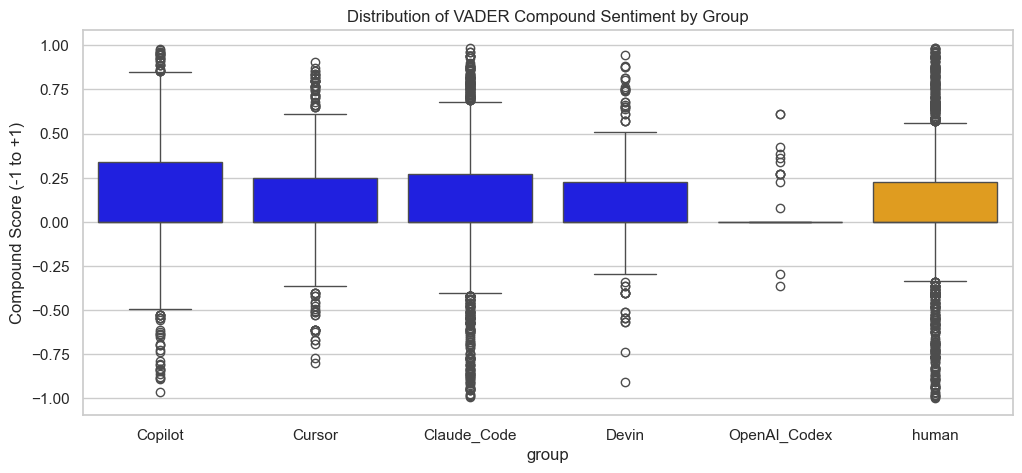

C:\Users\otten\AppData\Local\Temp\ipykernel_17788\3674235613.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="compound", data=df_sentiment, palette={"Agentic":"blue", "Developer":"orange"})


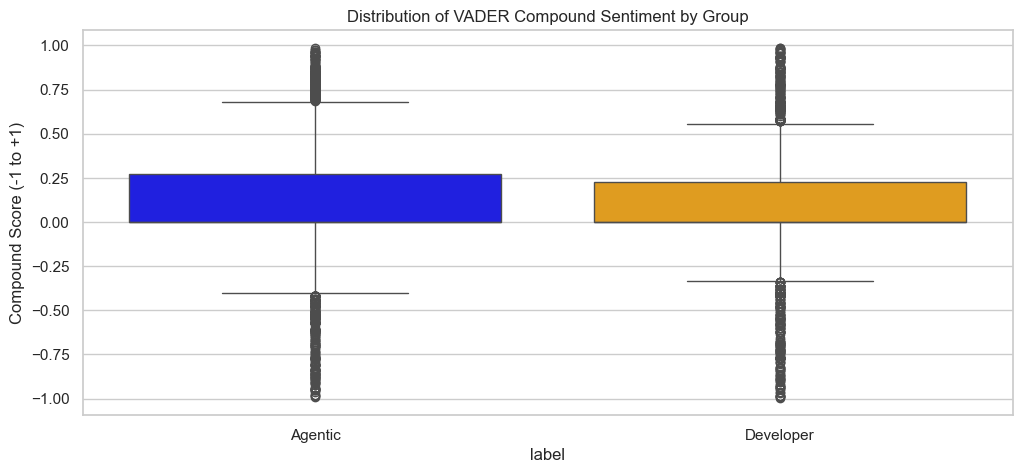

compound: U=4209788.50, p=2.0577e-02
flesch_reading_ease: U=3180244.50, p=1.8157e-45
smog_index: U=4612913.50, p=6.8203e-18
flesch_kincaid_grade: U=4763545.00, p=1.2498e-27


In [7]:
# Combine sentiment and readability metrics for summary
summary_metrics = [
    "neg", "neu", "pos", "compound",       # VADER
    "flesch_reading_ease", "smog_index", "flesch_kincaid_grade"
]

# Compute group-wise mean and std
summary_table = df_sentiment.groupby("group")[["neg","neu","pos","compound"]].mean().join(
    df_readability.groupby("group")[["flesch_reading_ease","smog_index","flesch_kincaid_grade"]].mean(),
    how="outer"
)

summary_table

sns.set(style="whitegrid")
plt.figure(figsize=(12,5))
sns.boxplot(x="group", y="compound", data=df_sentiment, palette={'Copilot':"blue", 'Claude_Code':"blue", 'Devin':"blue", 'human':"orange", 'OpenAI_Codex':"blue", 'Cursor':"blue"})
plt.title("Distribution of VADER Compound Sentiment by Group")
plt.ylabel("Compound Score (-1 to +1)")
plt.show()
sns.set(style="whitegrid")
plt.figure(figsize=(12,5))
sns.boxplot(x="label", y="compound", data=df_sentiment, palette={"Agentic":"blue", "Developer":"orange"})
plt.title("Distribution of VADER Compound Sentiment by Group")
plt.ylabel("Compound Score (-1 to +1)")
plt.show()
for metric in ["compound", "flesch_reading_ease", "smog_index", "flesch_kincaid_grade"]:
    a = df_sentiment[df_sentiment["label"]=="Agentic"][metric].dropna() if metric in df_sentiment else df_readability[df_readability["label"]=="Agentic"][metric].dropna()
    d = df_sentiment[df_sentiment["label"]=="Developer"][metric].dropna() if metric in df_sentiment else df_readability[df_readability["label"]=="Developer"][metric].dropna()
    stat, p = mannwhitneyu(a,d)
    print(f"{metric}: U={stat:.2f}, p={p:.4e}")

=== Sentiment Summary ===


neg                 neu                 pos            \
                  mean       std      mean       std      mean       std   
group                                                                      
Claude_Code   0.055956  0.115887  0.856739  0.170787  0.087301  0.133555   
Copilot       0.031875  0.090260  0.884831  0.161223  0.083293  0.136838   
Cursor        0.031011  0.095759  0.894968  0.164150  0.074018  0.138887   
Devin         0.027780  0.082023  0.913934  0.134012  0.058279  0.111841   
OpenAI_Codex  0.005906  0.027409  0.932264  0.140440  0.061830  0.135984   
human         0.034990  0.100908  0.910067  0.142850  0.054940  0.106659   

              compound            
                  mean       std  
group                             
Claude_Code   0.061018  0.367330  
Copilot       0.121469  0.325033  
Cursor        0.089630  0.279480  
Devin         0.087990  0.289628  
OpenAI_Codex  0.065402  0.178891  
human         0.059843  0.331423


=== Readability Summary ===


flesch_reading_ease            smog_index            \
                            mean        std       mean       std   
group                                                              
Claude_Code            27.780819  53.011241  10.908141  4.719329   
Copilot                31.061134  36.012382  11.464678  5.663785   
Cursor                 31.712879  69.864017   9.725451  5.029187   
Devin                  20.327868  77.589856  10.697213  5.591305   
OpenAI_Codex           38.914259  56.091187   7.851071  3.062914   
human                  36.182206  81.810921   9.670585  4.313056   

             flesch_kincaid_grade             
                             mean        std  
group                                         
Claude_Code             12.165922   8.120102  
Copilot                 12.450224   7.401903  
Cursor                  11.437368  10.533287  
Devin                   13.996489  12.318219  
OpenAI_Codex             9.445296   7.483639  
human                   11.224769  11.926611


=== Statistical Tests (Agentic vs Developer) ===
neg: U=4060527.50, p=7.5264e-01, r_rb=0.0035
neu: U=3744244.50, p=1.4098e-08, r_rb=0.0811
pos: U=4377761.00, p=3.1214e-08, r_rb=-0.0743
compound: U=4209788.50, p=2.0577e-02, r_rb=-0.0331
flesch_reading_ease: U=3180244.50, p=1.8157e-45, r_rb=0.2196
smog_index: U=4612913.50, p=6.8203e-18, r_rb=-0.1320
flesch_kincaid_grade: U=4763545.00, p=1.2498e-27, r_rb=-0.1690


C:\Users\otten\AppData\Local\Temp\ipykernel_17788\2635989860.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="compound", data=df_sentiment, palette={"Agentic":"blue","Developer":"orange"})


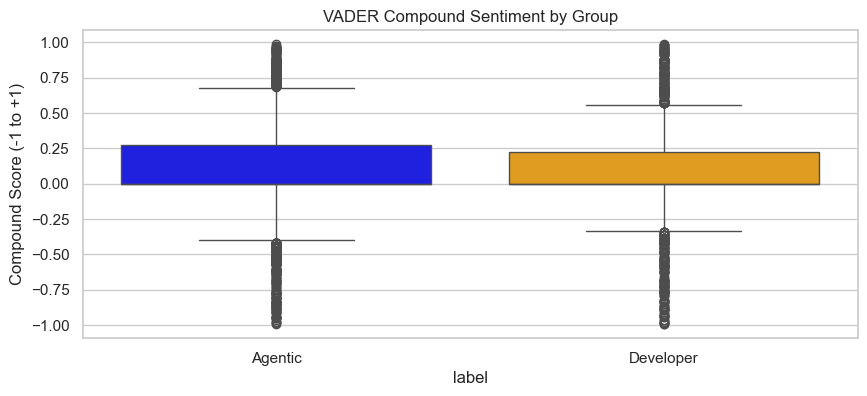

C:\Users\otten\AppData\Local\Temp\ipykernel_17788\2635989860.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=metric, data=df_readability, palette={"Agentic":"blue","Developer":"orange"})
C:\Users\otten\AppData\Local\Temp\ipykernel_17788\2635989860.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=metric, data=df_readability, palette={"Agentic":"blue","Developer":"orange"})
C:\Users\otten\AppData\Local\Temp\ipykernel_17788\2635989860.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=metric, da

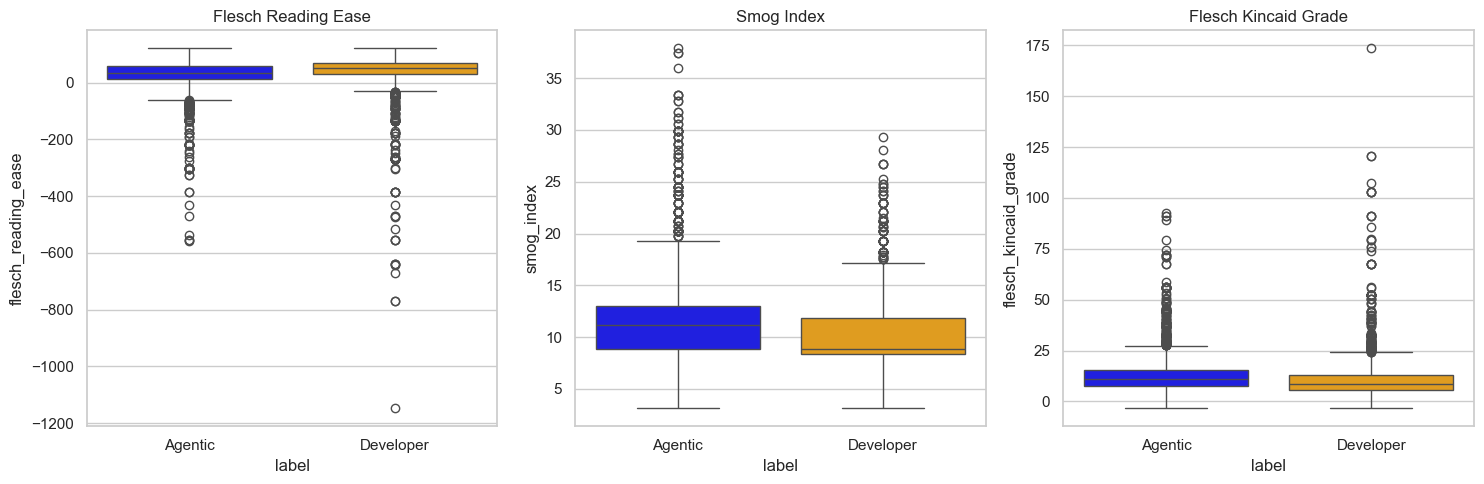

In [15]:
# Combine sentiment and readability into one table
sentiment_metrics = ["neg","neu","pos","compound"]
readability_metrics = ["flesch_reading_ease","smog_index","flesch_kincaid_grade"]

# Aggregate mean and std per group
summary_sentiment = df_sentiment.groupby("group")[sentiment_metrics].agg(["mean","std"])
summary_readability = df_readability.groupby("group")[readability_metrics].agg(["mean","std"])
# summary_sentiment = df_sentiment.groupby("group")[sentiment_metrics].agg(["median","std"])
# summary_readability = df_readability.groupby("group")[readability_metrics].agg(["median","std"])
print("=== Sentiment Summary ===")
display(summary_sentiment)
print("\n=== Readability Summary ===")
display(summary_readability)

# Statistical comparison (Mann-Whitney U)
print("\n=== Statistical Tests (Agentic vs Developer) ===")
for metric in sentiment_metrics + readability_metrics:
    if metric in df_sentiment.columns:
        a = df_sentiment[df_sentiment["label"]=="Agentic"][metric].dropna()
        d = df_sentiment[df_sentiment["label"]=="Developer"][metric].dropna()
    else:
        a = df_readability[df_readability["label"]=="Agentic"][metric].dropna()
        d = df_readability[df_readability["label"]=="Developer"][metric].dropna()
    
    n1 = len(a)
    n2 = len(d)

    stat, p = mannwhitneyu(a, d)

    rbc = 1 - (2 * stat) / (n1 * n2)

    print(f"{metric}: U={stat:.2f}, p={p:.4e}, r_rb={rbc:.4f}")
 
# Plot sentiment compound
plt.figure(figsize=(10,4))
sns.boxplot(x="label", y="compound", data=df_sentiment, palette={"Agentic":"blue","Developer":"orange"})
plt.title("VADER Compound Sentiment by Group")
plt.ylabel("Compound Score (-1 to +1)")
plt.show()

# Plot readability metrics
plt.figure(figsize=(15,5))
for i, metric in enumerate(readability_metrics):
    plt.subplot(1,3,i+1)
    sns.boxplot(x="label", y=metric, data=df_readability, palette={"Agentic":"blue","Developer":"orange"})
    plt.title(metric.replace("_"," ").title())
plt.tight_layout()
plt.show()